|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 0:</h2>|<h1>From a Program to a Model<h1>|
|<h2>Section:</h2>|<h1>Attention<h1>|
|<h2>Lecture:</h2>|<h1><b>Attention is a lookup<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

rng = np.random.default_rng(0)

def softmax(scores, axis=-1):
  exponentials = np.exp(scores - scores.max(axis=axis, keepdims=True))
  return exponentials / exponentials.sum(axis=axis, keepdims=True)

# A lookup that returns a mix

You know a dictionary. You give a key, and you get the one value stored under
it. A key matches exactly, or it does not match.

**Attention** is a lookup where each key matches a little. The result is a mix
of ALL the values, with more of the values whose keys match well. This
notebook builds that lookup from a dictionary, in four steps. It needs no GPU.

### Step 1: keys that are vectors

Make each key a vector. The thing that you look up with, the **query**, is also
a vector. The dot product of the query and a key measures how well they match: it is large when the two point in the
same direction.

Softmax turns the match scores into weights that add up to 1. The result is
the weighted sum of the values.

In [2]:
keys = np.array([[1.0, 0.0],      # four directions
                 [0.0, 1.0],
                 [-1.0, 0.0],
                 [0.0, -1.0]])
values = np.array([[10.0, 0.0, 0.0],
                   [0.0, 10.0, 0.0],
                   [0.0, 0.0, 10.0],
                   [5.0, 5.0, 5.0]])

def soft_lookup(query, keys, values):
  """-> (the weighted mix of the values, the weight of each value)."""
  scores = keys @ query              # one dot product for each key
  weights = softmax(scores)
  return weights @ values, weights

for query in ([3.0, 0.0], [2.0, 2.0], [0.0, 0.0]):
  result, weights = soft_lookup(np.array(query), keys, values)
  print(f'query {str(query):>11}: weights {np.round(weights, 2)}  ->  result {np.round(result, 1)}')

query  [3.0, 0.0]: weights [0.91 0.05 0.   0.05]  ->  result [9.3 0.7 0.2]
query  [2.0, 2.0]: weights [0.49 0.49 0.01 0.01]  ->  result [5.  5.  0.1]
query  [0.0, 0.0]: weights [0.25 0.25 0.25 0.25]  ->  result [3.8 3.8 3.8]


The first query points at key 0, so the result is almost value 0. The second
query points between key 0 and key 1, so the result is half of each. The zero
query matches all keys the same, so the result is the average.

### Step 2: a sharper match

Make the query longer, and the scores grow. Softmax then gives almost all the
weight to the best key. In the limit, the soft lookup becomes a normal
dictionary lookup.

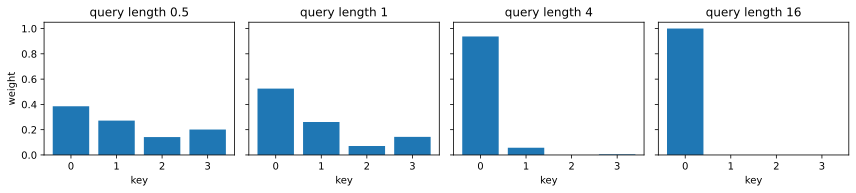

In [3]:
direction = np.array([1.0, 0.3])
lengths = [0.5, 1, 4, 16]
fig, axes = plt.subplots(1, len(lengths), figsize=(12, 2.8), sharey=True)
for axis, length in zip(axes, lengths):
  _, weights = soft_lookup(length * direction, keys, values)
  axis.bar(range(len(keys)), weights)
  axis.set(title=f'query length {length}', xlabel='key', xticks=range(len(keys)))
axes[0].set_ylabel('weight')
plt.tight_layout()
plt.show()

### Step 3: each token is all three

In a model, the lookup runs over the tokens of the text. Each token makes
three vectors from its hidden state, with three weight matrices:

- a **query**: what this token looks for.
- a **key**: what this token offers to other queries.
- a **value**: what this token gives if a query picks it.

Each token then does a soft lookup with its query, over the keys and values
of the tokens. One more rule applies: a token can look only at itself and at
EARLIER tokens. It cannot look at a token that the model did not write yet.
That rule is the **causal mask**. The tokens that a token can see are its
**context**.

All the lookups of all the tokens are one matrix product. Here are 6 tokens,
each a vector of 8 numbers.

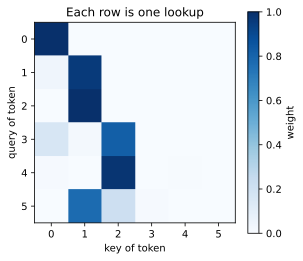

each row adds up to 1: True


In [4]:
NUM_TOKENS, HIDDEN = 6, 8
hidden_states = rng.normal(size=(NUM_TOKENS, HIDDEN))
query_weight, key_weight, value_weight = (rng.normal(size=(HIDDEN, HIDDEN)) for _ in range(3))

def causal_attention(hidden_states):
  """-> (the output of each token, the weights of each lookup)."""
  queries = hidden_states @ query_weight
  keys = hidden_states @ key_weight
  values = hidden_states @ value_weight
  scores = queries @ keys.T / np.sqrt(HIDDEN)        # all the dot products at one time
  future = np.triu(np.ones_like(scores, dtype=bool), k=1)
  scores[future] = -np.inf                          # the causal mask: no later tokens
  weights = softmax(scores)
  return weights @ values, weights

outputs, weights = causal_attention(hidden_states)
plt.figure(figsize=(4.5, 4))
plt.imshow(weights, cmap='Blues')
plt.colorbar(label='weight')
plt.xlabel('key of token')
plt.ylabel('query of token')
plt.title('Each row is one lookup')
plt.show()
print('each row adds up to 1:', np.allclose(weights.sum(axis=1), 1))

Row *i* is the lookup of token *i*. The top-right half is zero: that is the
causal mask. Token 0 can see only itself, so its output is its own value.

The division by the square root of the vector length keeps the scores small
when the vectors are long. Without it, softmax gives almost all the weight to
one key, as in step 2.

### Step 4: attention cannot see the order

Swap two earlier tokens, and look at the output of the LAST token. Its lookup
sees the same set of keys and values. The order of the set does not change a
weighted sum.

In [5]:
swapped = hidden_states.copy()
swapped[[1, 3]] = swapped[[3, 1]]              # swap token 1 and token 3
last_before = causal_attention(hidden_states)[0][-1]
last_after = causal_attention(swapped)[0][-1]
print('the last token sees no difference:', np.allclose(last_before, last_after))

the last token sees no difference: True


But "the dog bit the man" and "the man bit the dog" are different texts. So a
model must add the position of each token.

Modern models use **RoPE**, rotary position embedding. It rotates each query
and each key by an angle that grows with the position of its token. The dot
product of two rotated vectors then depends on the DISTANCE between the two
tokens. Here is the smallest version of it: rotate each pair of numbers.

In [6]:
def rope(vectors, positions, base=100.0):
  """Rotate each pair of numbers by an angle that grows with the position."""
  half = vectors.shape[-1] // 2
  frequencies = base ** (-np.arange(half) / half)
  angles = positions[:, None] * frequencies[None, :]
  first, second = vectors[:, :half], vectors[:, half:]
  return np.concatenate([first * np.cos(angles) - second * np.sin(angles),
                         first * np.sin(angles) + second * np.cos(angles)], axis=-1)

def causal_attention_with_rope(hidden_states):
  positions = np.arange(len(hidden_states))
  queries = rope(hidden_states @ query_weight, positions)
  keys = rope(hidden_states @ key_weight, positions)
  values = hidden_states @ value_weight
  scores = queries @ keys.T / np.sqrt(HIDDEN)
  scores[np.triu(np.ones_like(scores, dtype=bool), k=1)] = -np.inf
  return softmax(scores) @ values

last_before = causal_attention_with_rope(hidden_states)[-1]
last_after = causal_attention_with_rope(swapped)[-1]
print('with RoPE, the last token sees the swap:', not np.allclose(last_before, last_after))

with RoPE, the last token sees the swap: True


### What to remember from this notebook

- **Attention** is a soft lookup. A **query** scores each **key** with a dot
  product. Softmax turns the scores into weights. The result is the weighted
  mix of the **values**.
- Each token makes its own query, key and value from its hidden state.
- The **causal mask** lets a token see only itself and earlier tokens: its
  **context**.
- Attention alone does not see the order of the tokens. **RoPE** adds the
  positions to the queries and the keys.

The next notebook finds the fact that makes a fast inference engine possible:
the keys and values of earlier tokens never change.